In [ ]:
import pandas as pd
import numpy as np
import pickle
import os

# NLP & Machine Learning Libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.multiclass import OneVsRestClassifier

print("✅ Libraries Imported")

✅ Libraries Imported


In [ ]:
# Download the dataset (approx 10MB)
!wget -q https://zenodo.org/records/10579179/files/osdg-community-data-v2024-01-01.csv -O osdg_dataset.csv

# Load into Pandas
df = pd.read_csv("osdg_dataset.csv", sep='\t')

print(f"✅ Dataset Loaded. Total Rows: {df.shape[0]}")
print(df.head(3))

✅ Dataset Loaded. Total Rows: 42635
                          doi                           text_id  \
0  10.6027/9789289342698-7-en  00021941702cd84171ff33962197ca1f   
1        10.18356/eca72908-en  00028349a7f9b2485ff344ae44ccfd6b   
2  10.1787/9789264289062-4-en  0004eb64f96e1620cd852603d9cbe4d4   

                                                text  sdg  labels_negative  \
0  From a gender perspective, Paulgaard points ou...    5                1   
1  Labour legislation regulates maximum working h...   11                2   
2  The average figure also masks large difference...    3                1   

   labels_positive  agreement  
0                8   0.777778  
1                1   0.333333  
2                8   0.777778  


In [ ]:
# Filter: Keep only rows where agreement > 0.6 (High quality data)
df_clean = df[df['agreement'] > 0.6].copy()

# Select only the text and the label
df_clean = df_clean[['text', 'sdg']]

# Check the distribution (How many projects per SDG?)
print("✅ Data Cleaned")
print(df_clean['sdg'].value_counts().sort_index())

✅ Data Cleaned
sdg
1     1257
2      932
3     1885
4     2437
5     2724
6     1507
7     1915
8      875
9     1415
10     887
11    1288
12     514
13    1129
14     785
15    1184
16    2912
Name: count, dtype: int64


In [ ]:
# Create the Vectorizer
# max_features=20000: Keeps the top 20,000 most important words
# ngram_range=(1,2): Looks at single words ("water") and pairs ("clean water")
tfidf = TfidfVectorizer(stop_words='english', max_features=20000, ngram_range=(1,2))

# Transform the text data
X = tfidf.fit_transform(df_clean['text'])
y = df_clean['sdg']

print(f"✅ Text Converted to Numbers. Shape: {X.shape}")

✅ Text Converted to Numbers. Shape: (23646, 20000)


In [ ]:
# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Wrap the model to allow independent probabilities for each SDG
clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='liblinear'))

# Train the model
print("⚙️ Training Model... (This may take 10-20 seconds)")
clf.fit(X_train, y_train)

print("✅ Training Complete!")

⚙️ Training Model... (This may take 10-20 seconds)
✅ Training Complete!


In [ ]:
# Predict on the test set
y_pred = clf.predict(X_test)

# Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {acc:.2%}")

# Show detailed report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

🎯 Model Accuracy: 85.33%

Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.75      0.80       252
           2       0.85      0.84      0.84       207
           3       0.87      0.90      0.89       381
           4       0.86      0.91      0.88       476
           5       0.87      0.88      0.88       578
           6       0.90      0.85      0.88       299
           7       0.85      0.91      0.88       411
           8       0.65      0.54      0.59       169
           9       0.77      0.84      0.80       270
          10       0.79      0.63      0.70       163
          11       0.79      0.85      0.82       243
          12       0.88      0.63      0.73        94
          13       0.87      0.81      0.84       247
          14       0.95      0.86      0.90       145
          15       0.87      0.88      0.88       219
          16       0.89      0.97      0.93       576

    accuracy          

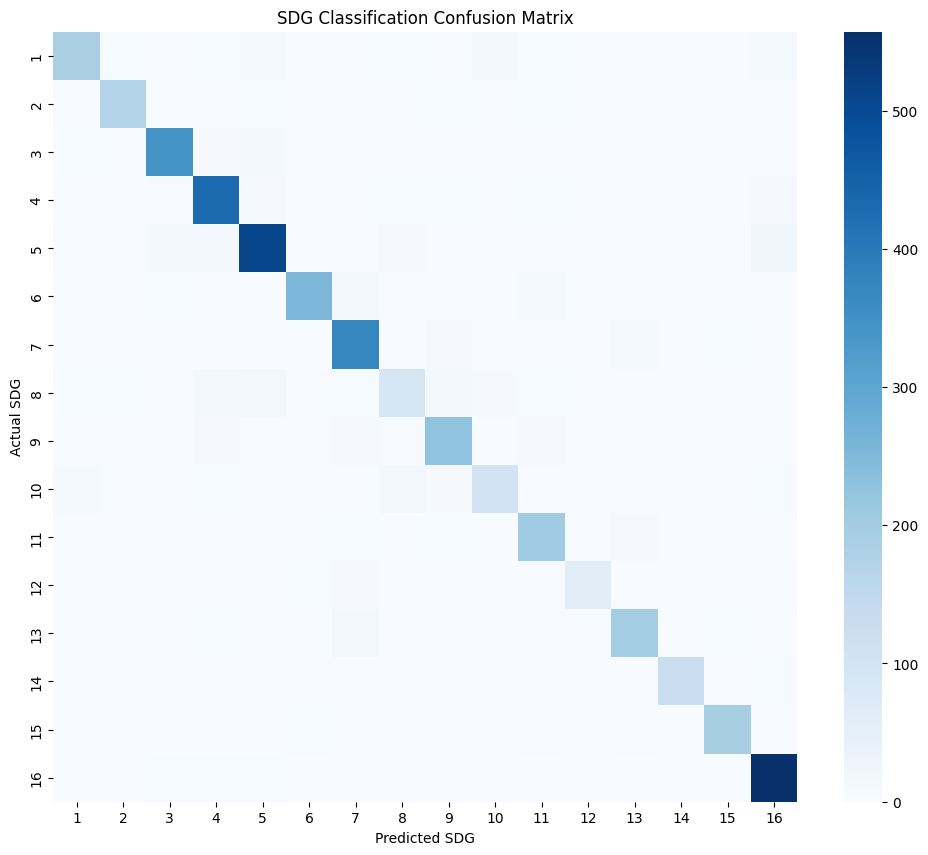

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('SDG Classification Confusion Matrix')
plt.xlabel('Predicted SDG')
plt.ylabel('Actual SDG')
plt.show()

In [ ]:
# ... (Ensure you have run the training step with OneVsRestClassifier first!) ...

def predict_sdg(project_text, threshold=0.15):
    vec_text = tfidf.transform([project_text])
    probabilities = clf.predict_proba(vec_text)[0]

    # DEBUG: Print ALL scores to see what the model is thinking
    print("\n🔍 DEBUG - Raw Probabilities:")
    all_scores = [(clf.classes_[i], score) for i, score in enumerate(probabilities)]
    all_scores.sort(key=lambda x: x[1], reverse=True)

    for sdg, score in all_scores:
        print(f"   SDG {sdg}: {score:.2%}") # This will show you SDG 3's score
    print("-" * 30)

    # ... keep the rest of your filtering logic below ...
    results = []
    for idx, score in enumerate(probabilities):
        if score > threshold:
            results.append((clf.classes_[idx], score))

    results.sort(key=lambda x: x[1], reverse=True)
    return results



In [ ]:
# --- TEST WITH A MULTI-TOPIC SENTENCE ---
# This text mixes "Solar" (SDG 7), "Schools" (SDG 4), and "Health" (SDG 3)
multi_topic_input = "We are installing solar panels on rural clinics and schools to ensure electricity for vaccines and digital learning."

predictions = predict_sdg(multi_topic_input)

print(f"📝 Project: {multi_topic_input}")
print("✅ Predicted SDGs:")

if not predictions:
    print("   No SDGs found above threshold.")
else:
    for sdg, conf in predictions:
        print(f"   - SDG {sdg} ({conf:.2%} confidence)")


🔍 DEBUG - Raw Probabilities:
   SDG 7: 44.92%
   SDG 4: 30.02%
   SDG 9: 6.66%
   SDG 3: 3.16%
   SDG 16: 1.98%
   SDG 6: 1.85%
   SDG 11: 1.63%
   SDG 5: 1.54%
   SDG 2: 1.24%
   SDG 15: 1.18%
   SDG 14: 1.08%
   SDG 1: 1.03%
   SDG 10: 1.02%
   SDG 8: 0.99%
   SDG 13: 0.97%
   SDG 12: 0.73%
------------------------------
📝 Project: We are installing solar panels on rural clinics and schools to ensure electricity for vaccines and digital learning.
✅ Predicted SDGs:
   - SDG 7 (44.92% confidence)
   - SDG 4 (30.02% confidence)


In [ ]:
# Save both the Vectorizer and the Classifier
with open('sdg_classifier_real.pkl', 'wb') as f:
    pickle.dump((tfidf, clf), f)

print("💾 Model saved as 'sdg_classifier_real.pkl'")
print("👉 Go to the Files tab (left sidebar) to download it!")

💾 Model saved as 'sdg_classifier_real.pkl'
👉 Go to the Files tab (left sidebar) to download it!
